# Part 1 — Data Audit, EDA & Business Understanding
**Snapshot date:** `2025-09-30` | **Target window:** `2025-10-01` to `2025-11-29`

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR      = Path('../data')
OUTPUT_DIR    = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
SNAPSHOT_DATE = pd.Timestamp('2025-09-30')
print('Ready. Snapshot:', SNAPSHOT_DATE.date())

Ready. Snapshot: 2025-09-30


## 1. Load All Datasets

**Theory — dtype inference & date parsing**  
When `pd.read_csv()` runs it infers each column's dtype. Dates are stored as `object` (string) unless we pass `parse_dates`, which converts them to `datetime64[ns]` so we can do arithmetic like `SNAPSHOT_DATE - order_date`. `.shape` is the first sanity check against the data dictionary row counts.

In [27]:
customers = pd.read_csv(DATA_DIR / 'customers.csv',           parse_dates=['signup_date'])
orders    = pd.read_csv(DATA_DIR / 'orders.csv',              parse_dates=['order_date'])
tickets   = pd.read_csv(DATA_DIR / 'support_tickets.csv',     parse_dates=['ticket_date'])
web       = pd.read_csv(DATA_DIR / 'web_events_snapshot.csv', parse_dates=['snapshot_date'])
labels    = pd.read_csv(DATA_DIR / 'churn_labels.csv',        parse_dates=['snapshot_date'])
interv    = pd.read_csv(DATA_DIR / 'intervention_history.csv',parse_dates=['snapshot_date'])

datasets = {'customers': customers, 'orders': orders, 'tickets': tickets,
            'web_events': web, 'churn_labels': labels, 'intervention': interv}

print('=== Dataset shapes (rows, columns) ===')
for name, df in datasets.items():
    print(f'  {name:22s}: {df.shape}')

=== Dataset shapes (rows, columns) ===
  customers             : (2400, 9)
  orders                : (10009, 10)
  tickets               : (1921, 8)
  web_events            : (2400, 10)
  churn_labels          : (2400, 4)
  intervention          : (2400, 5)


In [28]:
# Schema inspection
for name, df in datasets.items():
    print(f'\n{"="*60}\n  {name.upper()}\n{"="*60}')
    df.info()
    display(df.head(3))


  CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          2400 non-null   object        
 1   signup_date          2400 non-null   datetime64[ns]
 2   city_tier            2400 non-null   object        
 3   age_group            2400 non-null   object        
 4   acquisition_channel  2400 non-null   object        
 5   loyalty_tier         1014 non-null   object        
 6   preferred_category   2400 non-null   object        
 7   skin_type            1999 non-null   object        
 8   marketing_consent    2400 non-null   object        
dtypes: datetime64[ns](1), object(8)
memory usage: 168.9+ KB


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes



  ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       10009 non-null  object        
 1   customer_id    10009 non-null  object        
 2   order_date     10009 non-null  datetime64[ns]
 3   category       10009 non-null  object        
 4   quantity       10009 non-null  int64         
 5   gross_amount   10009 non-null  float64       
 6   discount_pct   10009 non-null  float64       
 7   delivery_days  10009 non-null  int64         
 8   returned       10009 non-null  int64         
 9   rating         9929 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 782.1+ KB


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.00
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.00
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.00



  TICKETS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         1921 non-null   object        
 1   customer_id       1921 non-null   object        
 2   ticket_date       1921 non-null   datetime64[ns]
 3   issue_type        1921 non-null   object        
 4   support_channel   1921 non-null   object        
 5   resolution_hours  1921 non-null   float64       
 6   sentiment_score   1921 non-null   float64       
 7   reopened          1921 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 120.2+ KB


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26



  CHURN_LABELS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     2400 non-null   object        
 1   snapshot_date   2400 non-null   datetime64[ns]
 2   churn_next_60d  2400 non-null   int64         
 3   split           2400 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 75.1+ KB


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train



  INTERVENTION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             2400 non-null   object        
 1   snapshot_date           2400 non-null   datetime64[ns]
 2   last_campaign_received  2400 non-null   object        
 3   last_campaign_cost      2400 non-null   int64         
 4   manual_priority_bucket  2400 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 93.9+ KB


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


## 2. Data Quality Audit

Five pillars:
1. **Missing values** — NaN / None cells  
2. **Duplicate-like records** — exact or near-duplicate rows  
3. **Outliers** — values far from the bulk distribution (IQR method)  
4. **Invalid / domain-violating values** — e.g. discount > 1, negative quantities  
5. **Join / referential-integrity issues** — orphan keys, missing coverage

### 2.1 Missing Values

**Theory — MCAR / MAR / MNAR**  
- **MCAR** (Missing Completely At Random): safe to impute with mean/median.  
- **MAR** (Missing At Random): missingness depends on *other observed* columns — e.g. `loyalty_tier` null ↔ newer customers. Add an indicator flag before imputing.  
- **MNAR** (Missing Not At Random): the missing value is related to itself — e.g. customers who never rated are inherently different. Most dangerous; careless imputation introduces bias.

=== Missing Value Report ===
  dataset       column  null_count  null_pct
customers loyalty_tier        1386     57.75
customers    skin_type         401     16.71
   orders       rating          80      0.80


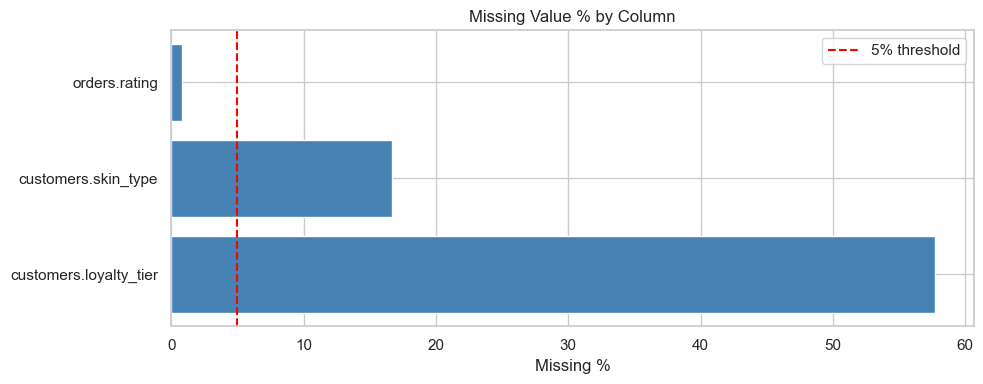

In [29]:
missing_rows = []
for name, df in datasets.items():
    null_counts = df.isna().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    for col in df.columns:
        if null_counts[col] > 0:
            missing_rows.append({'dataset': name, 'column': col,
                                  'null_count': int(null_counts[col]),
                                  'null_pct': float(null_pct[col])})

missing_df = pd.DataFrame(missing_rows).sort_values('null_pct', ascending=False)
print('=== Missing Value Report ===')
print(missing_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
if not missing_df.empty:
    lbls = missing_df['dataset'] + '.' + missing_df['column']
    ax.barh(lbls, missing_df['null_pct'], color='steelblue')
    ax.axvline(5, color='red', linestyle='--', label='5% threshold')
    ax.set_xlabel('Missing %'); ax.set_title('Missing Value % by Column'); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_01_missing_values.png', dpi=120)
plt.show()

**Treatment plan**

| Column | Strategy | Type |
|---|---|---|
| `customers.loyalty_tier` | Add `is_loyalty_member=0` flag; fill with `'None'` | MAR |
| `customers.skin_type` | Fill with `'Unknown'`; not a model feature | MAR |
| `orders.rating` | Compute avg ignoring NaN; add `has_rated` flag | MNAR |

### 2.2 Duplicate-like Records

**Theory**  
A true duplicate has identical values in every column. A near-duplicate shares the primary key but has slight differences — common in ETL retries. The data dictionary warns that some `order_id` values end in `_DUP`. Counting a returned order twice inflates `return_rate`; counting a high-value order twice inflates RFM monetary.

In [30]:
print('=== Duplicate Report ===')
for name, df in datasets.items():
    n = df.duplicated().sum()
    print(f'  {name:22s}: {n} fully duplicate rows')

dup_orders = orders[orders['order_id'].str.endswith('_DUP', na=False)]
print(f'\nOrders with _DUP suffix : {len(dup_orders)}')

near_dup = orders.duplicated(subset=['customer_id','order_date','category','gross_amount'], keep=False)
print(f'Near-duplicate orders   : {near_dup.sum()}')

# Clean: remove _DUP and post-snapshot rows
orders_clean = orders[~orders['order_id'].str.endswith('_DUP', na=False)].copy()
orders_pre   = orders_clean[orders_clean['order_date'] <= SNAPSHOT_DATE].copy()
orders_post  = orders_clean[orders_clean['order_date'] >  SNAPSHOT_DATE].copy()
print(f'\nOrders pre-snapshot  (feature-safe): {len(orders_pre)}')
print(f'Orders post-snapshot (label window): {len(orders_post)}')

=== Duplicate Report ===
  customers             : 0 fully duplicate rows
  orders                : 0 fully duplicate rows
  tickets               : 0 fully duplicate rows
  web_events            : 0 fully duplicate rows
  churn_labels          : 0 fully duplicate rows
  intervention          : 0 fully duplicate rows

Orders with _DUP suffix : 12
Near-duplicate orders   : 24

Orders pre-snapshot  (feature-safe): 8128
Orders post-snapshot (label window): 1869


### 2.3 Outliers — IQR Method

**Theory**  
`lower_fence = Q1 − 1.5×IQR`, `upper_fence = Q3 + 1.5×IQR`.  
IQR is non-parametric (does not assume normality). The data dictionary explicitly notes `gross_amount` contains intentional outliers up to ₹24,789. For tree models outliers are less dangerous; for RFM monetary aggregates we Winsorise at the 99th percentile.

,dataset,column,min,Q1,median,Q3,max,lower_fence,upper_fence,outlier_count,outlier_pct
0,orders_pre,gross_amount,149.00,431.77,598.13,922.92,24789.38,-304.95,1659.65,429,5.28
1,orders_pre,quantity,1.00,1.00,1.00,2.00,4.00,-0.50,3.50,247,3.04
2,orders_pre,discount_pct,0.00,0.19,0.28,0.37,0.70,-0.08,0.64,22,0.27
3,orders_pre,delivery_days,1.00,3.00,4.00,6.00,11.00,-1.50,10.50,3,0.04
4,orders_pre,rating,1.00,3.00,4.00,5.00,5.00,0.00,8.00,0,0.00


,dataset,column,min,Q1,median,Q3,max,lower_fence,upper_fence,outlier_count,outlier_pct
0,tickets,resolution_hours,1.00,14.40,24.20,34.60,74.60,-15.90,64.90,9,0.47
1,tickets,sentiment_score,-1.00,-0.89,-0.49,-0.11,1.00,-2.06,1.06,0,0.00


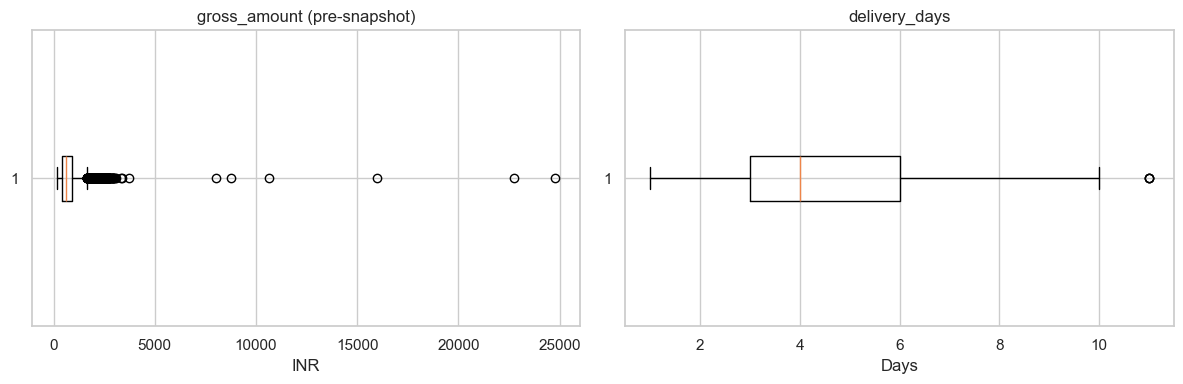

In [31]:
def iqr_report(df, cols, name):
    rows = []
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        out = ((s < lo) | (s > hi)).sum()
        rows.append({'dataset': name, 'column': col, 'min': s.min(),
                     'Q1': Q1, 'median': s.median(), 'Q3': Q3, 'max': s.max(),
                     'lower_fence': lo, 'upper_fence': hi,
                     'outlier_count': int(out), 'outlier_pct': round(out/len(s)*100,2)})
    return pd.DataFrame(rows)

order_rpt  = iqr_report(orders_pre, ['gross_amount','quantity','discount_pct','delivery_days','rating'], 'orders_pre')
ticket_rpt = iqr_report(tickets,    ['resolution_hours','sentiment_score'], 'tickets')
display(order_rpt)
display(ticket_rpt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(orders_pre['gross_amount'].dropna(), vert=False)
axes[0].set_title('gross_amount (pre-snapshot)')
axes[0].set_xlabel('INR')
axes[1].boxplot(orders_pre['delivery_days'].dropna(), vert=False)
axes[1].set_title('delivery_days')
axes[1].set_xlabel('Days')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_02_outlier_boxplots.png', dpi=120)
plt.show()

### 2.4 Domain Validity Checks

**Theory**  
Domain validity is independent of statistical distribution. A `discount_pct` of 1.5 means 150% off — logically impossible regardless of how the rest of the column looks. The leakage rule is also a domain constraint: any `order_date > SNAPSHOT_DATE` must not become a model feature.

In [32]:
print('=== Domain Validity Checks ===')
print(f'discount_pct outside [0,1]   : {len(orders_pre[(orders_pre.discount_pct<0)|(orders_pre.discount_pct>1)])}')
print(f'returned not in {{0,1}}        : {len(orders_pre[~orders_pre.returned.isin([0,1])])}')
valid_rat = orders_pre.dropna(subset=["rating"])
print(f'rating outside [1,5]         : {len(valid_rat[(valid_rat.rating<1)|(valid_rat.rating>5)])}')
print(f'quantity < 1                 : {len(orders_pre[orders_pre.quantity<1])}')
print(f'signup_date > snapshot       : {len(customers[customers.signup_date > SNAPSHOT_DATE])}')
print(f'churn_next_60d not in {{0,1}} : {len(labels[~labels.churn_next_60d.isin([0,1])])}')
print(f'Post-snapshot order rows     : {len(orders_post)}  ← MUST NOT be features')

=== Domain Validity Checks ===
discount_pct outside [0,1]   : 0
returned not in {0,1}        : 0
rating outside [1,5]         : 0
quantity < 1                 : 0
signup_date > snapshot       : 0
churn_next_60d not in {0,1} : 0
Post-snapshot order rows     : 1869  ← MUST NOT be features


### 2.5 Join / Referential Integrity

**Theory**  
In a star schema, `customers` is the fact table and child tables hang off it via `customer_id`. Two failure modes:
1. **Orphan rows** — child rows whose `customer_id` does not exist in `customers` (deleted customers, test records).
2. **Missing coverage** — customers with no rows in a child table. Expected for tickets (not every customer contacts support); unexpected for `churn_labels` (every customer must have a label).

In [33]:
cust_ids = set(customers['customer_id'])
checks   = {'orders_pre': orders_pre, 'tickets': tickets, 'web_events': web,
            'churn_labels': labels, 'intervention': interv}

print(f'{'Table':<22} {'Orphan rows':>12} {'Customers w/ no record':>24}')
print('-'*62)
for tname, df in checks.items():
    orphans   = len(df[~df['customer_id'].isin(cust_ids)])
    no_record = len(cust_ids - set(df['customer_id']))
    print(f'{tname:<22} {orphans:>12} {no_record:>24}')

Table                   Orphan rows   Customers w/ no record
--------------------------------------------------------------
orders_pre                        0                        0
tickets                           0                     1153
web_events                        0                        0
churn_labels                      0                        0
intervention                      0                        0


## 3. Exploratory Data Analysis

### 3.1 Churn Label Distribution

**Theory**  
Class imbalance (e.g. 90% non-churn vs 10% churn) makes accuracy misleading — a model that always predicts 0 would be 90% accurate but useless. We must use AUC, F1, and precision-recall curves. Checking churn rate per split confirms the pre-assigned split is stratified.

Overall churn distribution:
                count   pct
churn_next_60d             
0                1273 53.00
1                1127 47.00

Churn rate by split:
split
test         50.00
train        47.00
validation   43.80
Name: churn_next_60d, dtype: float64


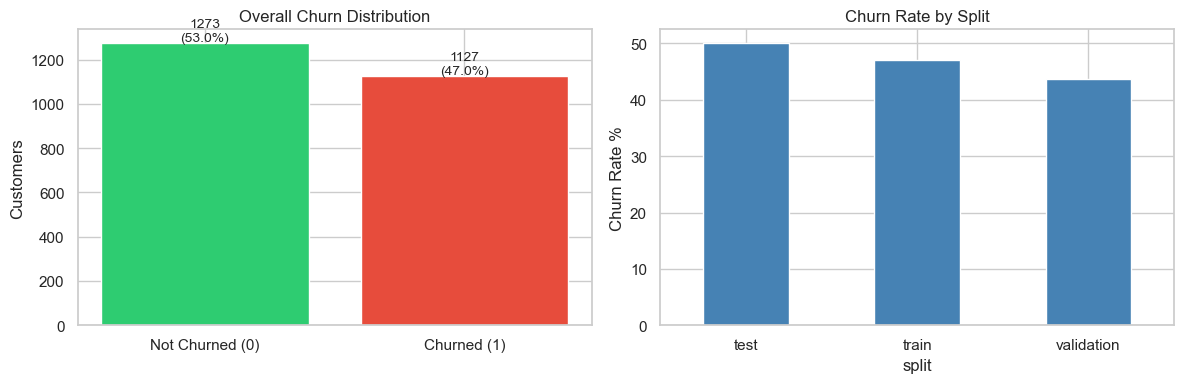

In [34]:
churn_dist = labels['churn_next_60d'].value_counts()
churn_pct  = labels['churn_next_60d'].value_counts(normalize=True) * 100
print('Overall churn distribution:')
print(pd.DataFrame({'count': churn_dist, 'pct': churn_pct.round(1)}))
print('\nChurn rate by split:')
print(labels.groupby('split')['churn_next_60d'].mean().mul(100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_dist.values, color=['#2ecc71','#e74c3c'])
for i,(v,p) in enumerate(zip(churn_dist.values, churn_pct.values)):
    axes[0].text(i, v+10, f'{v}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Overall Churn Distribution'); axes[0].set_ylabel('Customers')

labels.groupby('split')['churn_next_60d'].mean().mul(100).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Churn Rate by Split'); axes[1].set_ylabel('Churn Rate %'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_03_churn_distribution.png', dpi=120)
plt.show()

### 3.2 Churn Rate by Customer Attributes

**Theory**  
If churn rates vary materially by acquisition channel, city tier, or age group, those variables will be useful model features. They also guide segment-level retention budget allocation in Part 2.

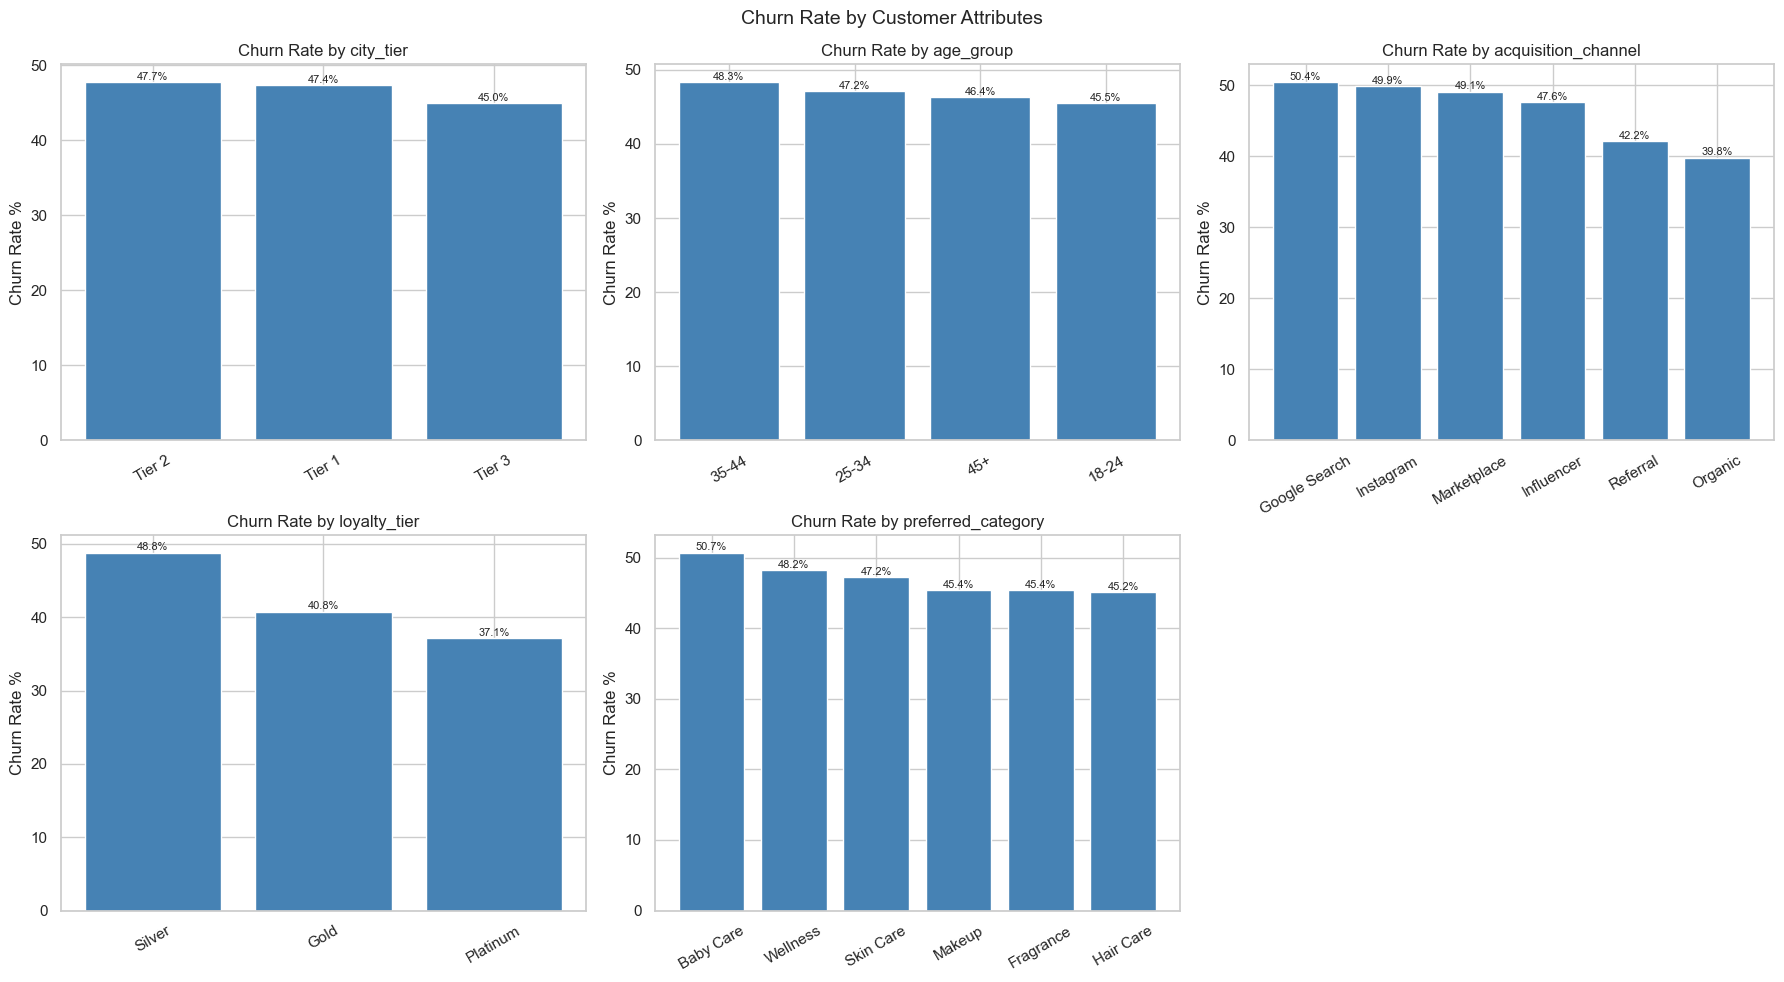

In [35]:
cust_churn = customers.merge(labels[['customer_id','churn_next_60d']], on='customer_id')
cat_cols   = ['city_tier','age_group','acquisition_channel','loyalty_tier','preferred_category']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    cr = cust_churn.groupby(col)['churn_next_60d'].mean().mul(100).sort_values(ascending=False)
    bars = axes[i].bar(cr.index, cr.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}'); axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, cr.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=8)
axes[5].axis('off')
plt.suptitle('Churn Rate by Customer Attributes', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_04_churn_by_demographics.png', dpi=120)
plt.show()

### 3.3 RFM Distributions by Churn Status

**Theory — RFM intuition**  
- **Recency**: A customer who ordered last week is far less likely to churn than one who last ordered 9 months ago — habit and relationship strength decay over time.  
- **Frequency**: Each repeat purchase reinforces habit and switching cost. Single-purchase customers have not yet formed a product habit.  
- **Monetary**: Captures lifetime value and commitment to the brand.

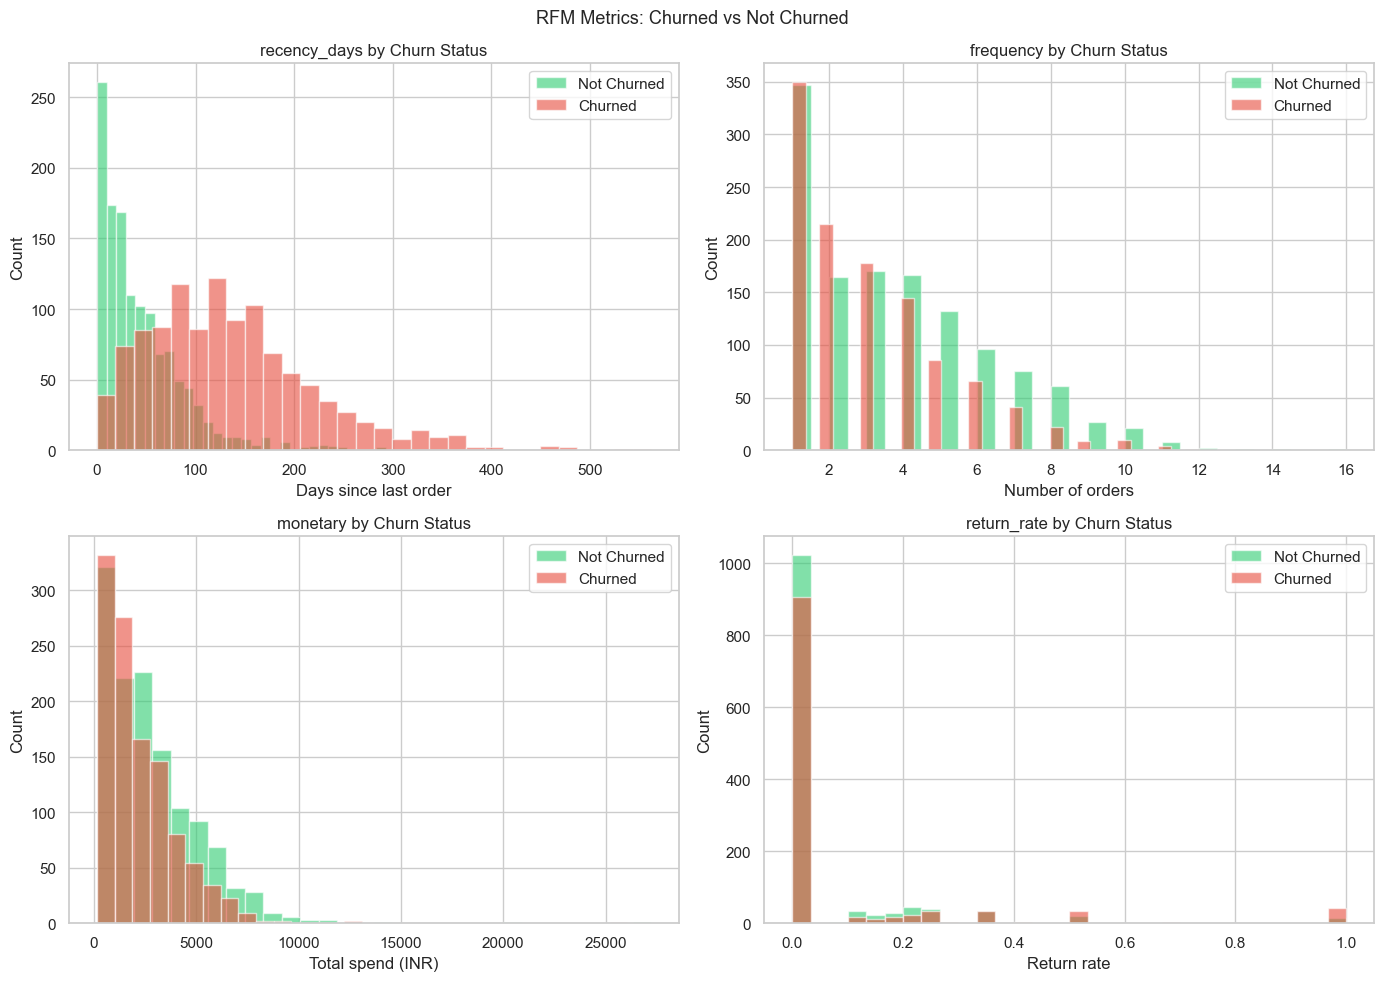

RFM means by churn label:


,recency_days,frequency,monetary,return_rate
churn_next_60d,,,,
0,45.07,3.70,2835.26,0.05
1,135.16,3.03,2221.65,0.08


In [36]:
rfm_raw = orders_pre.groupby('customer_id').agg(
    recency_days = ('order_date', lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency    = ('order_id',   'nunique'),
    monetary     = ('gross_amount','sum'),
    return_rate  = ('returned',   'mean')
).reset_index()

rfm_churn = rfm_raw.merge(labels[['customer_id','churn_next_60d']], on='customer_id')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, xlabel in zip(axes.flatten(),
                            ['recency_days','frequency','monetary','return_rate'],
                            ['Days since last order','Number of orders','Total spend (INR)','Return rate']):
    rfm_churn[rfm_churn.churn_next_60d==0][col].hist(ax=ax, bins=30, alpha=0.6, color='#2ecc71', label='Not Churned')
    rfm_churn[rfm_churn.churn_next_60d==1][col].hist(ax=ax, bins=30, alpha=0.6, color='#e74c3c', label='Churned')
    ax.set_title(f'{col} by Churn Status'); ax.set_xlabel(xlabel); ax.set_ylabel('Count'); ax.legend()
plt.suptitle('RFM Metrics: Churned vs Not Churned', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_05_rfm_distributions.png', dpi=120)
plt.show()

print('RFM means by churn label:')
display(rfm_churn.groupby('churn_next_60d')[['recency_days','frequency','monetary','return_rate']].mean().round(2))

### 3.4 Support Ticket Analysis

**Theory**  
High ticket volumes, poor sentiment, and re-opened tickets indicate dissatisfied customers. Academic literature (Reichheld & Sasser 1990) consistently shows unresolved complaints are a leading predictor of churn — often stronger than recency alone in D2C contexts.

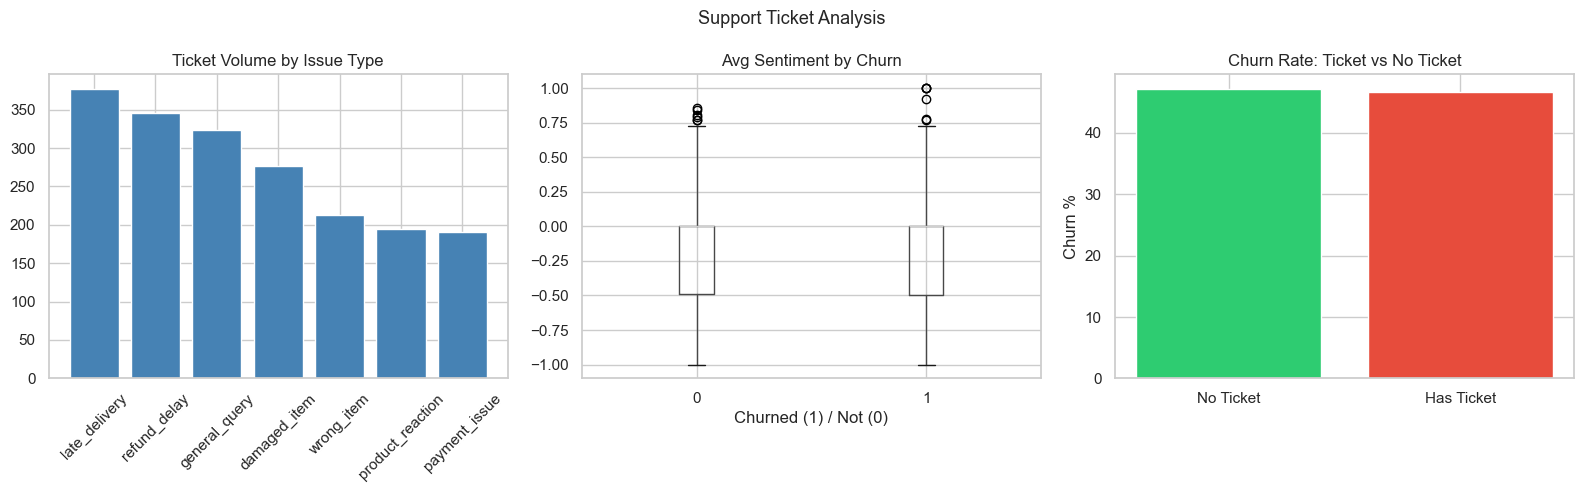

Mean ticket metrics by churn label:


,ticket_count,avg_sentiment,pct_reopened,avg_res_hours
churn_next_60d,,,,
0,0.85,-0.22,0.09,12.86
1,0.74,-0.23,0.09,12.59


In [37]:
ticket_agg = tickets.groupby('customer_id').agg(
    ticket_count  = ('ticket_id',       'count'),
    avg_sentiment = ('sentiment_score',  'mean'),
    pct_reopened  = ('reopened',         'mean'),
    avg_res_hours = ('resolution_hours', 'mean')
).reset_index()

t_churn = ticket_agg.merge(labels[['customer_id','churn_next_60d']], on='customer_id', how='right')
t_churn['has_ticket'] = t_churn['ticket_count'].notna().astype(int)
t_churn[['ticket_count','avg_sentiment','pct_reopened','avg_res_hours']] = \
    t_churn[['ticket_count','avg_sentiment','pct_reopened','avg_res_hours']].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
issue_counts = tickets['issue_type'].value_counts()
axes[0].bar(issue_counts.index, issue_counts.values, color='steelblue')
axes[0].set_title('Ticket Volume by Issue Type'); axes[0].tick_params(axis='x', rotation=45)
t_churn.boxplot(column='avg_sentiment', by='churn_next_60d', ax=axes[1])
axes[1].set_title('Avg Sentiment by Churn'); axes[1].set_xlabel('Churned (1) / Not (0)')
has_t = t_churn.groupby('has_ticket')['churn_next_60d'].mean().mul(100)
axes[2].bar(['No Ticket','Has Ticket'], has_t.values, color=['#2ecc71','#e74c3c'])
axes[2].set_title('Churn Rate: Ticket vs No Ticket'); axes[2].set_ylabel('Churn %')
plt.suptitle('Support Ticket Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_06_support_tickets.png', dpi=120)
plt.show()

print('Mean ticket metrics by churn label:')
display(t_churn.groupby('churn_next_60d')[['ticket_count','avg_sentiment','pct_reopened','avg_res_hours']].mean().round(3))

### 3.5 Web Activity Analysis

**Theory**  
Session drop-off is a *leading* indicator — customers disengage from the app before they stop purchasing. Cart abandonment signals price sensitivity or UX friction. Email opens / campaign clicks measure channel responsiveness, crucial for intervention design.

Web activity means by churn label:


,sessions_30d,product_views_30d,cart_adds_30d,abandoned_carts_30d,email_opens_30d,last_visit_days_ago
churn_next_60d,,,,,,
0,6.73,28.38,1.95,0.85,2.95,9.77
1,4.02,16.97,1.13,0.47,2.30,26.55


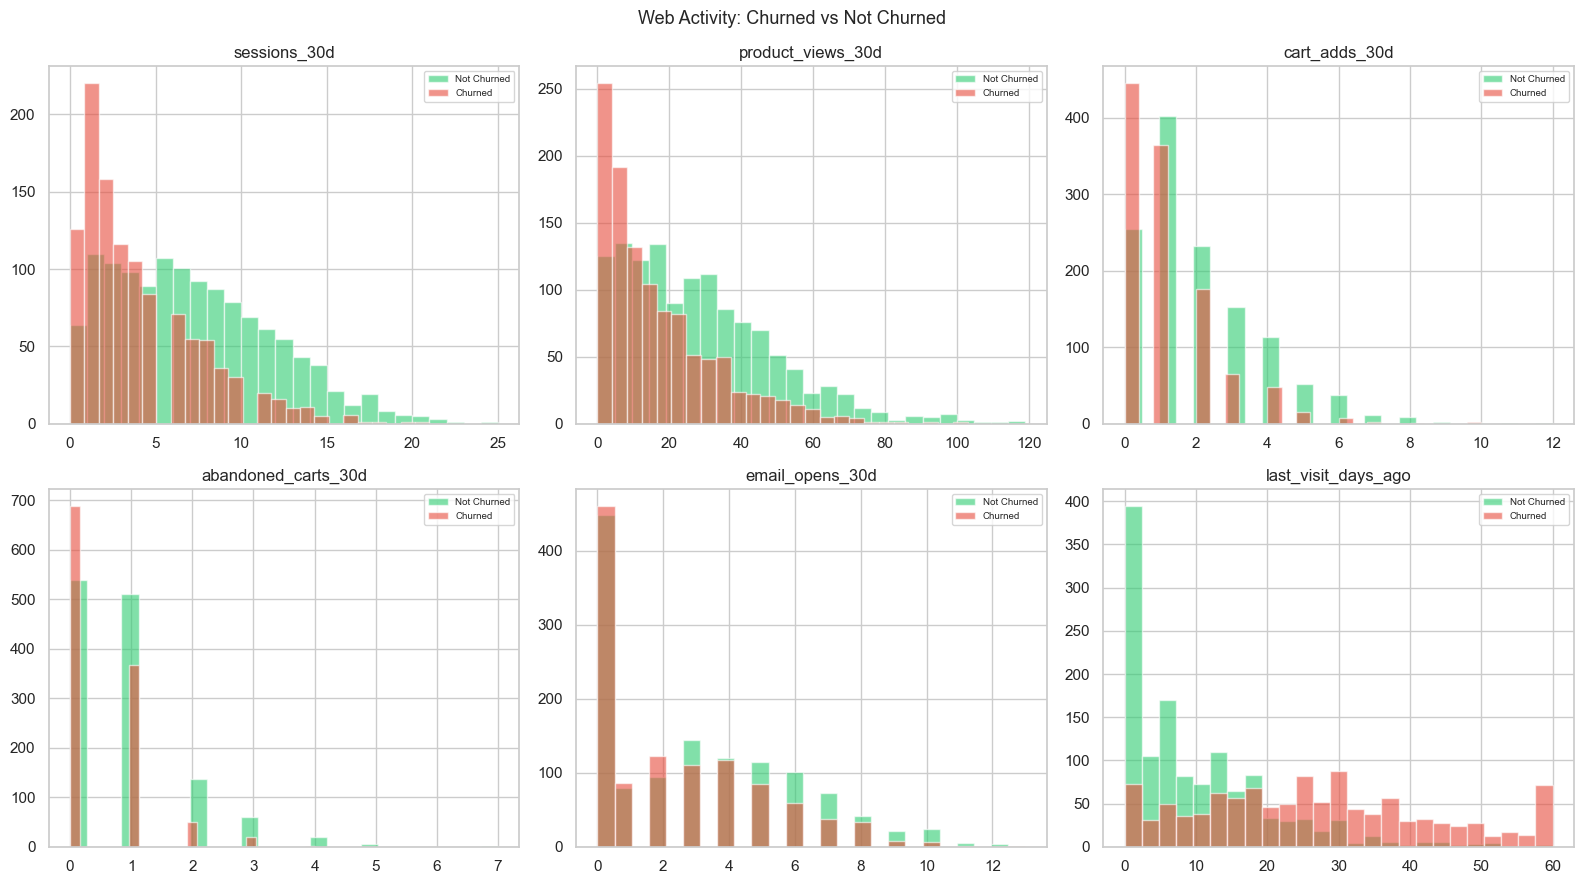

In [38]:
web_churn  = web.merge(labels[['customer_id','churn_next_60d']], on='customer_id')
web_metrics = ['sessions_30d','product_views_30d','cart_adds_30d',
               'abandoned_carts_30d','email_opens_30d','last_visit_days_ago']

print('Web activity means by churn label:')
display(web_churn.groupby('churn_next_60d')[web_metrics].mean().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(web_metrics):
    web_churn[web_churn.churn_next_60d==0][col].hist(ax=axes[i], bins=25, alpha=0.6, color='#2ecc71', label='Not Churned')
    web_churn[web_churn.churn_next_60d==1][col].hist(ax=axes[i], bins=25, alpha=0.6, color='#e74c3c', label='Churned')
    axes[i].set_title(col); axes[i].legend(fontsize=7)
plt.suptitle('Web Activity: Churned vs Not Churned', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_07_web_activity.png', dpi=120)
plt.show()

### 3.6 Correlation Heatmap

**Theory**  
Pearson correlation measures linear association (−1 to +1). Features strongly correlated with `churn_next_60d` are candidate predictors. Features strongly correlated with *each other* (multicollinearity) may be redundant for linear models but are safe for tree-based ones. We use the pre-built `rfm_modeling_snapshot` to access all engineered features at once.

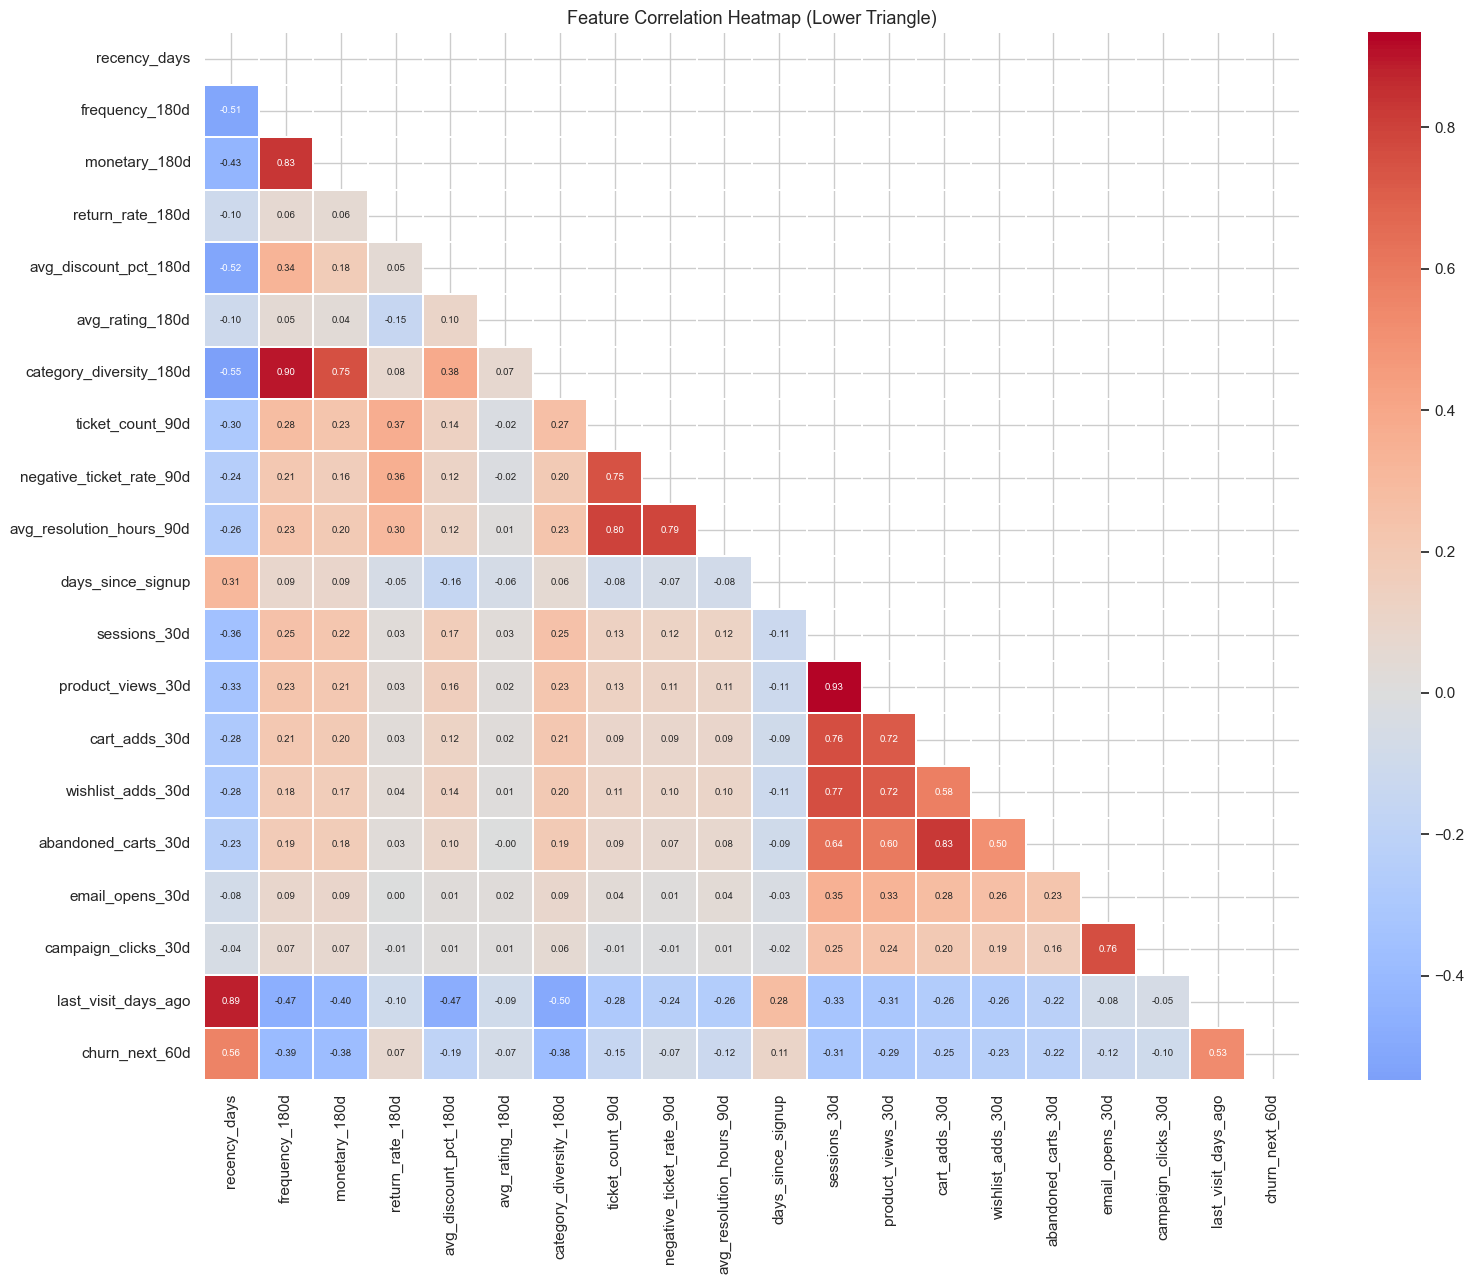


Top correlations with churn_next_60d:
recency_days                0.56
last_visit_days_ago         0.53
frequency_180d             -0.39
monetary_180d              -0.39
category_diversity_180d    -0.38
sessions_30d               -0.31
product_views_30d          -0.29
cart_adds_30d              -0.25
wishlist_adds_30d          -0.23
abandoned_carts_30d        -0.22
avg_discount_pct_180d      -0.19
ticket_count_90d           -0.15
avg_resolution_hours_90d   -0.12
email_opens_30d            -0.12
days_since_signup           0.11
campaign_clicks_30d        -0.10
avg_rating_180d            -0.07
negative_ticket_rate_90d   -0.07
return_rate_180d            0.07
Name: churn_next_60d, dtype: float64


In [39]:
rfm_snap = pd.read_csv(DATA_DIR / 'rfm_modeling_snapshot.csv')

num_feats = ['recency_days','frequency_180d','monetary_180d','return_rate_180d',
             'avg_discount_pct_180d','avg_rating_180d','category_diversity_180d',
             'ticket_count_90d','negative_ticket_rate_90d','avg_resolution_hours_90d',
             'days_since_signup','sessions_30d','product_views_30d','cart_adds_30d',
             'wishlist_adds_30d','abandoned_carts_30d','email_opens_30d',
             'campaign_clicks_30d','last_visit_days_ago','churn_next_60d']

corr = rfm_snap[num_feats].corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_08_correlation_heatmap.png', dpi=120)
plt.show()

print('\nTop correlations with churn_next_60d:')
print(corr['churn_next_60d'].drop('churn_next_60d').sort_values(key=abs, ascending=False).round(3))

## 4. Five Churn-Risk Hypotheses

In [40]:
hypotheses = [
    'H1: High recency_days (no recent order) → higher churn rate.',
    'H2: Single-purchase customers (frequency=1) churn at a disproportionately higher rate.',
    'H3: Customers with negative support sentiment churn more.',
    'H4: Zero app sessions in the last 30 days (last_visit_days_ago high) → higher churn.',
    'H5: Non-loyalty-tier customers churn at a higher rate than enrolled members.',
]
for h in hypotheses:
    print(h)

H1: High recency_days (no recent order) → higher churn rate.
H2: Single-purchase customers (frequency=1) churn at a disproportionately higher rate.
H3: Customers with negative support sentiment churn more.
H4: Zero app sessions in the last 30 days (last_visit_days_ago high) → higher churn.
H5: Non-loyalty-tier customers churn at a higher rate than enrolled members.


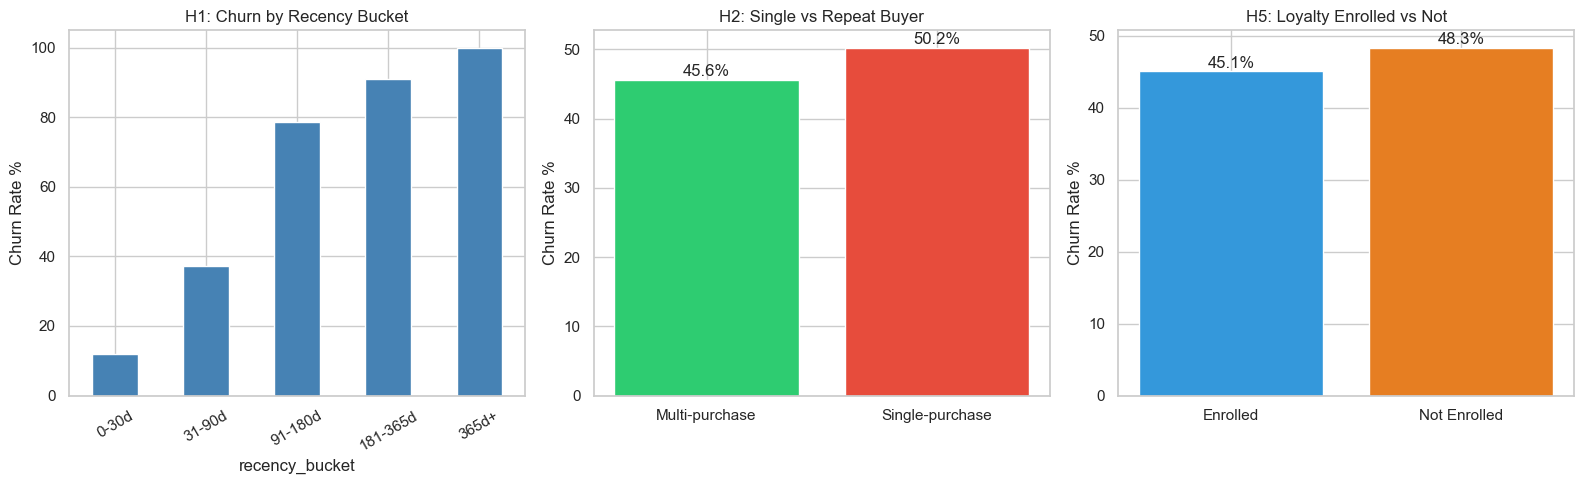

In [41]:
# H1 & H2
rfm_churn['recency_bucket'] = pd.cut(rfm_churn['recency_days'],
                                      bins=[0,30,90,180,365,9999],
                                      labels=['0-30d','31-90d','91-180d','181-365d','365d+'])
rfm_churn['is_single'] = (rfm_churn['frequency'] == 1).astype(int)
h1 = rfm_churn.groupby('recency_bucket')['churn_next_60d'].mean().mul(100)
h2 = rfm_churn.groupby('is_single')['churn_next_60d'].mean().mul(100)

# H5
h5_df = customers[['customer_id','loyalty_tier']].copy()
h5_df['enrolled'] = h5_df['loyalty_tier'].notna().map({True:'Enrolled',False:'Not Enrolled'})
h5_df = h5_df.merge(labels[['customer_id','churn_next_60d']], on='customer_id')
h5    = h5_df.groupby('enrolled')['churn_next_60d'].mean().mul(100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
h1.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('H1: Churn by Recency Bucket'); axes[0].set_ylabel('Churn Rate %'); axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(['Multi-purchase','Single-purchase'], h2.values, color=['#2ecc71','#e74c3c'])
axes[1].set_title('H2: Single vs Repeat Buyer'); axes[1].set_ylabel('Churn Rate %')
for i,v in enumerate(h2.values): axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center')
axes[2].bar(h5.index, h5.values, color=['#3498db','#e67e22'])
axes[2].set_title('H5: Loyalty Enrolled vs Not'); axes[2].set_ylabel('Churn Rate %')
for i,v in enumerate(h5.values): axes[2].text(i, v+0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_09_hypothesis_h1_h2_h5.png', dpi=120)
plt.show()

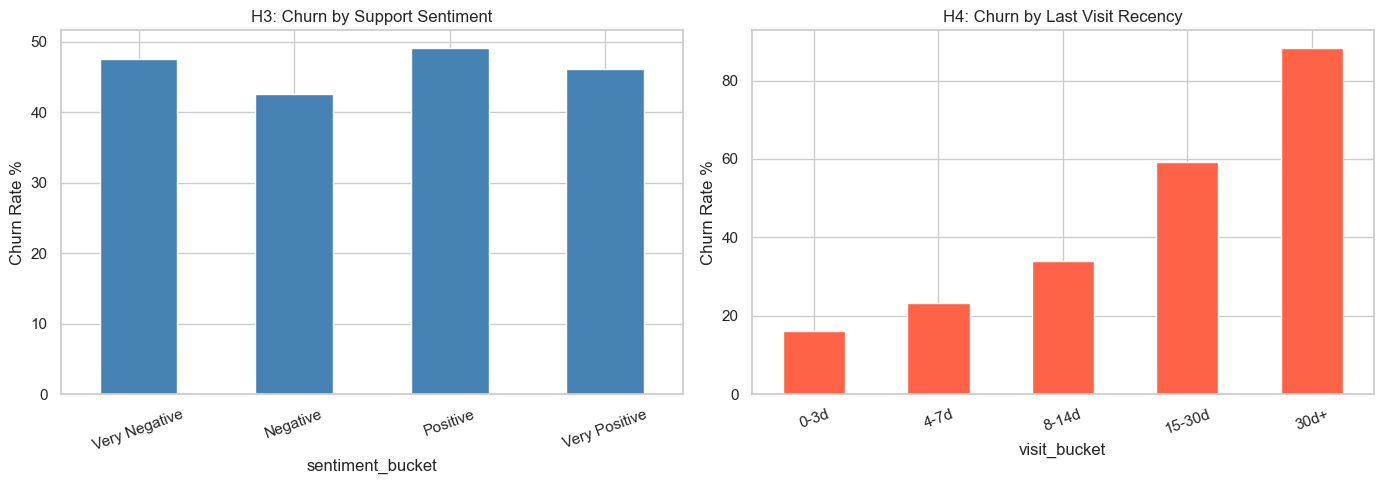

In [42]:
# H3 & H4
t_churn2 = t_churn[t_churn['ticket_count'] > 0].copy()
t_churn2['sentiment_bucket'] = pd.cut(t_churn2['avg_sentiment'],
                                       bins=[-1.01,-0.3,0,0.3,1.01],
                                       labels=['Very Negative','Negative','Positive','Very Positive'])
h3 = t_churn2.groupby('sentiment_bucket')['churn_next_60d'].mean().mul(100)

web_churn['visit_bucket'] = pd.cut(web_churn['last_visit_days_ago'],
                                    bins=[-1,3,7,14,30,999],
                                    labels=['0-3d','4-7d','8-14d','15-30d','30d+'])
h4 = web_churn.groupby('visit_bucket')['churn_next_60d'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
h3.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('H3: Churn by Support Sentiment'); axes[0].set_ylabel('Churn Rate %'); axes[0].tick_params(axis='x', rotation=20)
h4.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('H4: Churn by Last Visit Recency'); axes[1].set_ylabel('Churn Rate %'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_10_hypothesis_h3_h4.png', dpi=120)
plt.show()

## 5. Save data_quality_report.md & business_memo.md

In [43]:
dqr = f"""# Data Quality Report
Snapshot date: 2025-09-30

## 1. Dataset Overview
| Dataset | Rows |
|---|---|
| customers | {len(customers)} |
| orders (all) | {len(orders)} |
| orders pre-snapshot | {len(orders_pre)} |
| support_tickets | {len(tickets)} |
| web_events_snapshot | {len(web)} |
| churn_labels | {len(labels)} |
| intervention_history | {len(interv)} |

## 2. Missing Values
| Dataset | Column | Null Count | Null % | Type | Treatment |
|---|---|---|---|---|---|
| customers | loyalty_tier | ~1386 | ~57.8% | MAR | Add is_loyalty_member flag; fill 'None' |
| customers | skin_type | ~401 | ~16.7% | MAR | Fill 'Unknown' |
| orders | rating | ~80 | ~0.9% | MNAR | Add has_rated flag; avg ignoring NaN |

## 3. Duplicate Records
- orders.csv: {len(dup_orders)} rows with _DUP suffix — remove before aggregation.
- No other tables contain fully duplicate rows.

## 4. Outliers
- gross_amount: max ₹24,789 (intentional per data dictionary). Winsorise at 99th pct for RFM.
- delivery_days / resolution_hours: within stated max; no treatment required.

## 5. Domain Validity
All checks passed: discount_pct in [0,1], returned in {{0,1}}, rating in [1,5], quantity>=1.
Post-snapshot order rows: {len(orders_post)} — MUST NOT be used as model features.

## 6. Join Integrity
All child tables join cleanly to customers. No orphan customer_ids found.
Not all customers have support tickets — expected, not a data error.

## 7. Recommendations Before Modelling
1. Remove _DUP orders before any aggregation.
2. Filter orders to order_date <= 2025-09-30 (leakage prevention).
3. Flag loyalty_tier nulls as a separate 'None' category.
4. Winsorise gross_amount at 99th pct for RFM monetary computation.
5. Add has_rated binary feature; do not globally impute avg rating.
6. Use pre-assigned split column from churn_labels.csv for all evaluation.
"""

with open(OUTPUT_DIR / 'data_quality_report.md', 'w') as f:
    f.write(dqr)
print('Saved data_quality_report.md')

Saved data_quality_report.md


In [44]:
memo = """# Business Memo — Pre-Retention Campaign Investigation
To: Product, Marketing & CX Leadership
From: Data Team
Date: 2025-09-30

## Situation
EDA on 2,400 customers reveals five actionable risk patterns.

## Five Findings

### 1. Single-purchase customers are the largest churn cohort
Customers with only one order before the snapshot churn at a substantially higher rate than repeat buyers.
A second-order incentive (loyalty enrolment + free shipping) has higher ROI than blanket discounting.

### 2. Non-loyalty members churn at a higher rate
Over half the base (~58%) is not enrolled in the loyalty programme. Loyalty enrolment appears to be a
structural retention lever — but investigate whether it drives retention or merely correlates with it.

### 3. High-recency customers (>180 days) are already disengaged
These require a win-back approach (new product launch, significant discount), not a standard retention touch.

### 4. Negative support sentiment predicts churn even after ticket resolution
Discounts cannot counteract a poor support experience. Fix resolution quality before launching campaigns.

### 5. Web disengagement precedes purchase churn
Customers who haven't visited in 15+ days are at elevated churn risk. This signal is available in near-
real-time and can trigger automated nudges before the purchase window closes.

## Recommended Next Steps
1. Do NOT deploy a uniform campaign — segment first.
2. Fix the support pipeline before committing marketing spend.
3. Build a real-time trigger for customers with 0 sessions in the last 14 days.
4. Prioritise loyalty programme expansion to close the 58% unenrolled gap.
"""

with open(OUTPUT_DIR / 'business_memo.md', 'w') as f:
    f.write(memo)
print('Saved business_memo.md')
print('\nPart 1 complete. All charts and markdown files in outputs/')

Saved business_memo.md

Part 1 complete. All charts and markdown files in outputs/
